<a href="https://colab.research.google.com/github/KaranGupta2005/AQI_Predictor/blob/main/Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

***Transformation and Data Augmentation***

In [ ]:
transform=transforms.Compose([
    transforms.RandomRotation(10), # same image->different versions , slightly shifted/rotated/tilted
    transforms.ToTensor(), #convert images [0-255]-> tensor[0-1]
    transforms.Normalize((0.5,),(0.5,)) #stabilize training
])

In [ ]:
train_dataset=torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True,
)

train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)

test_dataset=torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
)

test_loader=DataLoader(test_dataset,batch_size=64,shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.84MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 157kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


***Data Visualization***



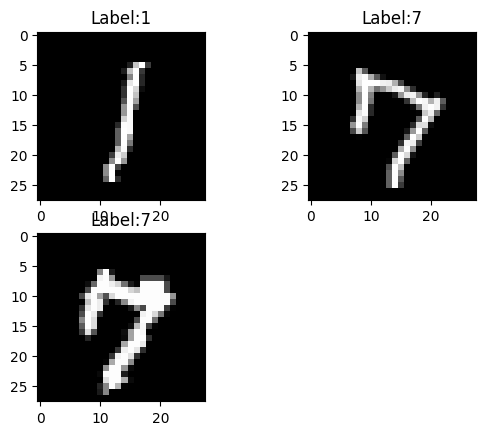

In [ ]:
import matplotlib.pyplot as plt

images,labels=next(iter(train_loader))
#iter-> iterator , next-> points to the first batch
plt.subplot(2,2,1)
plt.imshow(images[0].squeeze(),cmap='gray')
plt.title(f"Label:{labels[0]}")

plt.subplot(2,2,2)
plt.imshow(images[4].squeeze(),cmap='gray')
plt.title(f"Label:{labels[4]}")

plt.subplot(2,2,3)
plt.imshow(images[8].squeeze(),cmap='gray')
plt.title(f"Label:{labels[8]}")
#images of the MNIST->(Channels,Height,Width) -> squeeze reduce it to squeeze out the Channels dimensions
#cmap='gray'-> renders the images in grayscale

plt.show()

In [ ]:
import torch.nn as nn
import torch.optim as optim

***CNN Model***

In [ ]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN,self).__init__()

        self.conv=nn.Sequential(
            nn.Conv2d(1,32,3,padding=1,stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,3,padding=1,stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.fc=nn.Sequential(
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,10)
        )

    def forward(self,x):
        x=self.conv(x)

        #flattening
        x=x.view(-1,64*7*7)

        x=self.fc(x)

        return x

model=MNIST_CNN()

***Training Loop***

In [ ]:
criterion=nn.CrossEntropyLoss() #it combines Softmax and Log Loss
optimizer=optim.Adam(model.parameters(),lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(5):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

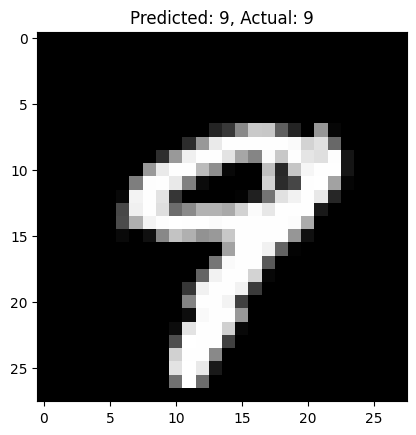

In [ ]:
import matplotlib.pyplot as plt

image, label = test_dataset[9]

with torch.no_grad():
    output = model(image.unsqueeze(0))
    _, pred = torch.max(output, 1)

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Predicted: {pred.item()}, Actual: {label}")
plt.show()